In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve
)
from keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

I0000 00:00:1773532025.146885  146334 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773532025.195807  146334 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773532026.423115  146334 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
CLASSES = ['Irritated', 'Neutral']

print("Loading model...")
model = load_model('models/binary_emotion_model.h5')

test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    'binary_data/test',
    target_size=(48, 48),
    color_mode='grayscale',
    batch_size=64,
    class_mode='binary',
    shuffle=False
)

print("Generating predictions...")
y_prob = model.predict(test_gen, verbose=1).flatten()
y_true = test_gen.classes
y_pred = (y_prob >= 0.5).astype(int)

print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true, y_pred, target_names=CLASSES))

Loading model...


I0000 00:00:1773532026.961385  146334 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1754 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Found 7178 images belonging to 2 classes.
Generating predictions...


I0000 00:00:1773532028.795108  146334 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1773532029.185243  146411 service.cc:153] XLA service 0x71684c036ee0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773532029.185272  146411 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 Ti Laptop GPU, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.6.0; Toolkit: 12.5.0; DNN: 9.10.2)
I0000 00:00:1773532029.195807  146411 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1773532029.320951  146411 cuda_dnn.cc:461] Loaded cuDNN version 91002


 16/113 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step

I0000 00:00:1773532032.496460  146411 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step

CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Irritated       0.85      0.85      0.85      4171
     Neutral       0.79      0.80      0.79      3007

    accuracy                           0.83      7178
   macro avg       0.82      0.82      0.82      7178
weighted avg       0.83      0.83      0.83      7178



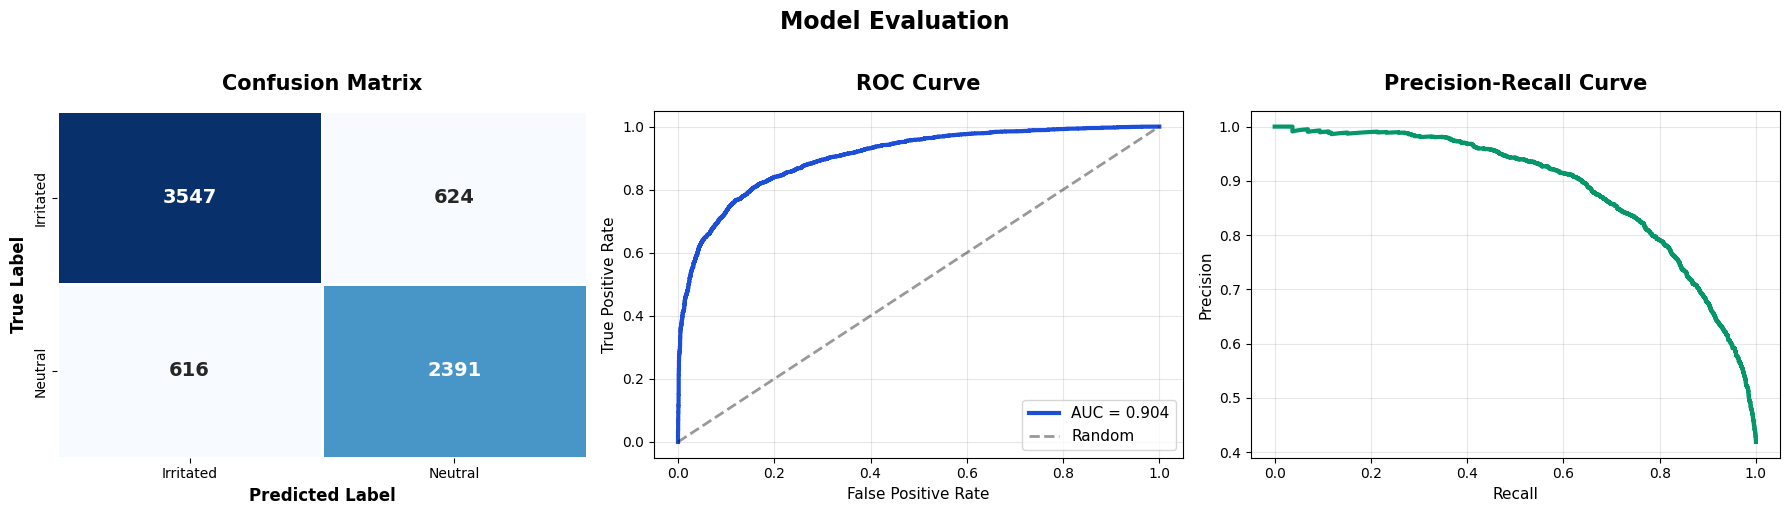

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Evaluation', fontsize=17, fontweight='bold', y=1.02)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
           xticklabels=CLASSES, yticklabels=CLASSES,
           ax=axes[0], linewidths=2, linecolor='white',
           annot_kws={'fontsize': 14, 'fontweight': 'bold'})
axes[0].set_title('Confusion Matrix', fontsize=15, fontweight='bold', pad=15)
axes[0].set_ylabel('True Label', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#1D4ED8', lw=3, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0,1], [0,1], 'k--', lw=2, alpha=0.4, label='Random')
axes[1].set_title('ROC Curve', fontsize=15, fontweight='bold', pad=15)
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].legend(loc='lower right', fontsize=11)
axes[1].grid(True, alpha=0.3)

# Precision-Recall Curve
prec, rec, thresholds = precision_recall_curve(y_true, y_prob)
axes[2].plot(rec, prec, color='#059669', lw=3)
axes[2].set_title('Precision-Recall Curve', fontsize=15, fontweight='bold', pad=15)
axes[2].set_xlabel('Recall', fontsize=11)
axes[2].set_ylabel('Precision', fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('models/evaluation_plots.png', dpi=150, bbox_inches='tight')
plt.show()